# Task 2: Customer Segmentation Using Unsupervised Learning

## Objective
Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

## Dataset Description
Mall Customers Dataset containing 200 rows and 5 columns — CustomerID, Gender, Age, Annual Income (k$), and Spending Score (1-100).

## Conclusion & Marketing Strategies

K-Means clustering identified 5 customer segments (optimal K found using Elbow Method). PCA was used to visualize clusters with 3 features compressed into 2 components.

**Segments & Strategies:**
1. **High Income, High Spending (VIPs):** Offer premium memberships, exclusive previews, and loyalty rewards.
2. **High Income, Low Spending (Careful Rich):** Targeted promotions and personalized offers to convert them into spenders.
3. **Low Income, High Spending (Impulsive Buyers):** Discount deals, installment plans, and flash sales.
4. **Average Income, Average Spending (Regulars):** Seasonal offers and referral programs to increase engagement.
5. **Low Income, Low Spending (Budget Customers):** Budget-friendly bundles and value deals.

In [1]:
# importing libraries
import numpy as np                      # for mathematical calculations
import pandas as pd                     # for handling data in tables
import seaborn as sns                   # for creating graphs
import matplotlib.pyplot as plt         # base plotting library

In [2]:
df = pd.read_csv('Mall_Customers.csv')  # loading dataset
df.head()  # displaying first 5 rows

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


(200, 5)
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


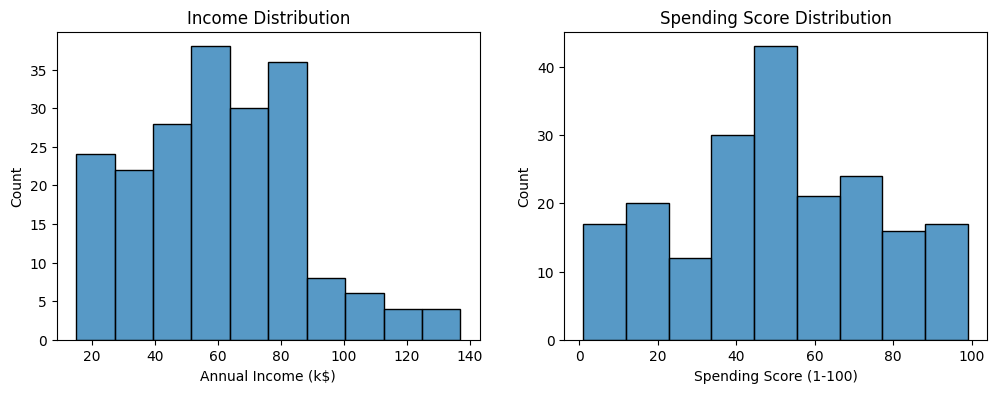

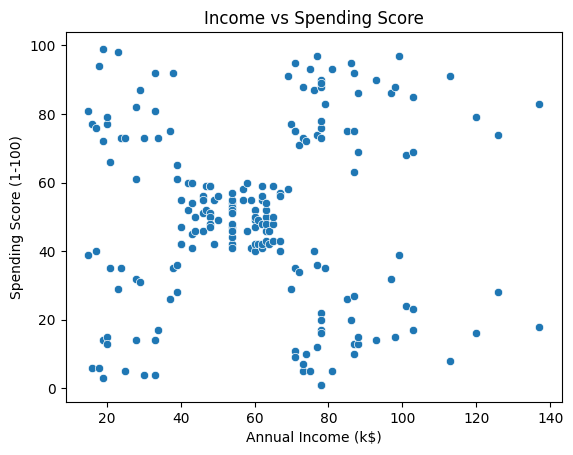

In [3]:
print(df.shape)  # rows and columns
print(df.isnull().sum())  # missing values check

# distribution of income and spending score
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Annual Income (k$)'], ax=axes[0])  # income distribution
axes[0].set_title('Income Distribution')
sns.histplot(df['Spending Score (1-100)'], ax=axes[1])  # spending distribution
axes[1].set_title('Spending Score Distribution')
plt.show()

# income vs spending scatter - clusters yahan dikhne shuru honge!
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title('Income vs Spending Score')
plt.show()

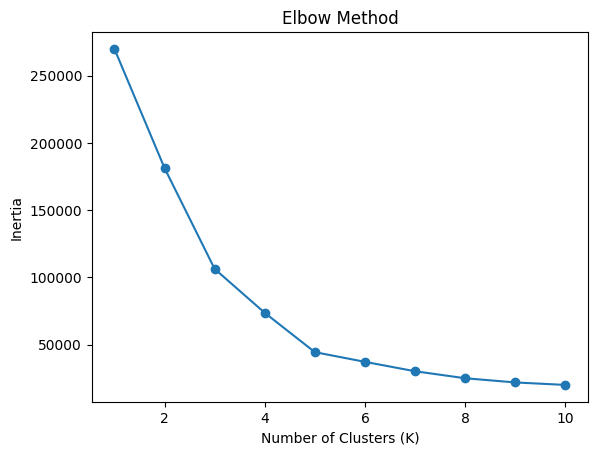

In [4]:
from sklearn.cluster import KMeans  # importing KMeans for clustering

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]  # selecting features for clustering

# elbow method to find best number of clusters
inertia = []  # list to store inertia (cluster tightness) for each k
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)  # creating kmeans with k clusters
    km.fit(X)  # fitting on data
    inertia.append(km.inertia_)  # saving inertia value

plt.plot(range(1, 11), inertia, marker='o')  # plotting elbow curve
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

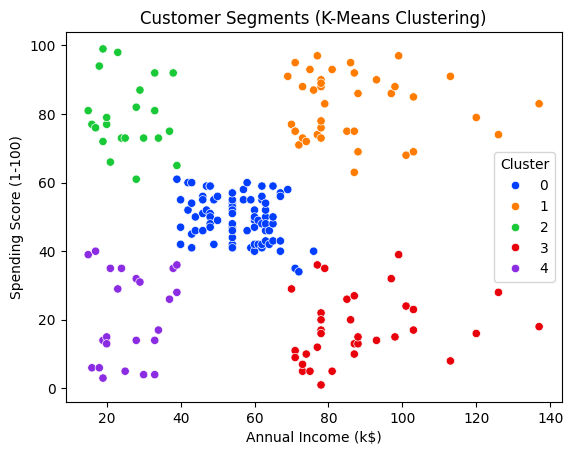

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # creating kmeans with 5 clusters
df['Cluster'] = kmeans.fit_predict(X)  # assigning each customer a cluster number

# visualizing the 5 customer segments
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='bright')
plt.title('Customer Segments (K-Means Clustering)')
plt.show()

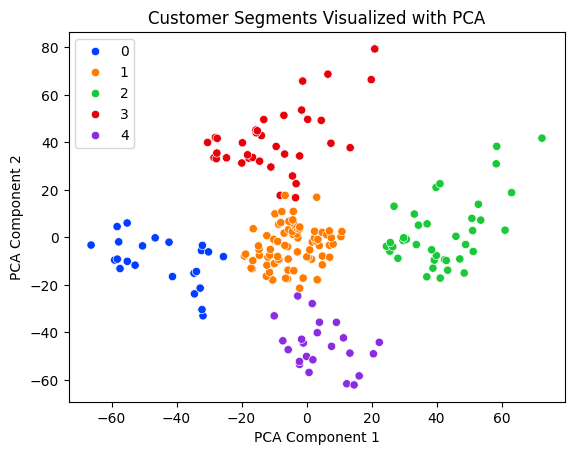

In [6]:
from sklearn.decomposition import PCA  # importing PCA for dimensionality reduction

X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]  # using 3 features now
kmeans3 = KMeans(n_clusters=5, random_state=42, n_init=10)  # kmeans with 5 clusters
clusters3 = kmeans3.fit_predict(X3)  # clustering on 3 features

pca = PCA(n_components=2)  # compressing 3 features into 2 components
X_pca = pca.fit_transform(X3)  # transforming data

# visualizing clusters in 2D using PCA
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters3, palette='bright')
plt.title('Customer Segments Visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()